# Treated MonoCulture Math Modelling — 20k IC75 (Julia)

Uses DifferentialEquations.jl + Optimization.jl with an ODEProblem and a Hill-type drug effect for IC75 analysis (1.47µM dose).

## 1) Packages
Load or install required Julia packages for treated IC75 modelling (logistic growth with Hill drug effect).

In [1]:
# 1) Packages (minimal)
using Pkg
pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations", "Optim", "Plots"
]
for p in pkgs
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end
println("✓ Packages ready: " * join(pkgs, ", "))

✓ Packages ready: CSV, DataFrames, Statistics, DifferentialEquations, Optim, Plots


## 2) Imports & Paths
Bring into scope the packages, set plotting defaults, and define filesystem paths.

In [2]:
# 2) Imports & Paths
using CSV, DataFrames, Statistics
using DifferentialEquations, Optimization, OptimizationOptimJL, BlackBoxOptim
using Optim
using Plots
default(fmt=:png, legend=:topright, lw=2, size=(900,550))

# Root and directories
ROOT = raw"c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics"
UNT_PARAMS = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")
TREATED_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "IC75")
mkpath(OUT_DIR)
println("Using treated averages dir: " * TREATED_DIR)
println("Output directory: " * OUT_DIR)

Using treated averages dir: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages
Output directory: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC75


## 3) Utilities (Loaders)
Helpers to load treated day averages and untreated baseline r,K parameters.

In [3]:
# 3) Utilities (Loaders)
function load_day_averages(path::AbstractString)
    @assert isfile(path) "Missing CSV: $path"
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : Symbol(first(filter(n -> occursin("day", lowercase(String(n))), names(df))))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : Symbol(first(filter(n -> occursin("mean", lowercase(String(n))) && occursin("cells", lowercase(String(n))), names(df))))
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]
    return x, y
end

function load_rk_table(csv_path::AbstractString)
    df = CSV.read(csv_path, DataFrame)
    # Filter for 20k density only and create lookup by CellLine
    df_20k = filter(row -> row.Density == "20k", df)
    return Dict(Symbol(row.CellLine) => (Float64(row.r), Float64(row.K)) for row in eachrow(df_20k))
end

println("Loaded utility functions")

Loaded utility functions


## 4) Model (Logistic with Hill Inhibition)
Defines Hill function, ODE, and solver for IC75=1.47µM treatment. Only the Hill coefficient (n) is estimated.

In [4]:
# 4) Model (Single IC50 with Separate Coefficients) - CONSISTENT MODEL
# One Hill effect with different coefficients for growth rate and carrying capacity
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

function treated_logistic!(du, u, p, t)
    r, K, IC50, n, dose, α_r, α_K = p
    
    # Single Hill inhibition effect
    inhibition = hill(dose, IC50, n)
    
    # Apply different fractions of the inhibition to each parameter
    r_eff = r * (1 - α_r * inhibition)  # α_r fraction affects growth rate
    K_eff = K * (1 - α_K * inhibition)  # α_K fraction affects carrying capacity
    
    # Logistic growth with both effects from same Hill curve
    du[1] = r_eff * u[1] * (1 - u[1] / K_eff)
end

function solve_model(x::Vector{Float64}, y::Vector{Float64}, r, K; 
                    IC50=1.0, n=1.0, dose=1.47, α_r=0.0, α_K=1.0, density="20k")
    # Set day 0 cell count based on seeding density (20k for this notebook)
    day0_cells = if density == "30k"
        100.0
    elseif density == "20k"
        67.0
    else
        max(y[1], eps())  # fallback to original behavior
    end
    
    u0 = [day0_cells]; tspan = (x[1], x[end])
    p = [r, K, IC50, n, dose, α_r, α_K]
    prob = ODEProblem(treated_logistic!, u0, tspan, p)
    sol = solve(prob, Rosenbrock23(); saveat=x, reltol=1e-6, abstol=1e-6)
    return sol
end

println("CONSISTENT SINGLE IC50 Model for IC75 Analysis (1.47µM dose)")
println("  - IC50: Single dose-response curve")
println("  - n: Hill coefficient for the dose-response")
println("  - α_r: Fraction of inhibition affecting growth rate (0-1)")
println("  - α_K: Fraction of inhibition affecting carrying capacity (0-1)")
println("  - Same Hill inhibition, different allocation to r vs K")
println("  - Applied dose: 1.47µM (IC75 of naive cells)")

Model ready (IC75 = 1.47µM dose, estimating Hill coefficient n)


In [ ]:
# Enhanced Normalized Loss Function for Better Optimization
function normalized_loss(data_naive, data_cis, p)
    r, K, α_r_naive, α_K_naive, α_r_cis, α_K_cis = p
    
    # Fixed IC50 values for consistency across all dose notebooks
    IC50_naive = 1.0     # µM
    IC50_cis = 3.16      # µM
    n = 1.0              # Hill coefficient
    dose = 1.47          # IC75 applied dose (µM)
    
    x_naive, y_naive = data_naive[:, 1], data_naive[:, 2]
    x_cis, y_cis = data_cis[:, 1], data_cis[:, 2]
    
    try
        sol_naive = solve_model(x_naive, y_naive, r, K; IC50=IC50_naive, n=n, dose=dose, 
                               α_r=α_r_naive, α_K=α_K_naive, density="20k")
        sol_cis = solve_model(x_cis, y_cis, r, K; IC50=IC50_cis, n=n, dose=dose, 
                             α_r=α_r_cis, α_K=α_K_cis, density="20k")
        
        y_pred_naive = [sol_naive(t)[1] for t in x_naive]
        y_pred_cis = [sol_cis(t)[1] for t in x_cis]
        
        # Normalize data to [0,1] range for balanced loss computation
        y_naive_min, y_naive_max = minimum(y_naive), maximum(y_naive)
        y_cis_min, y_cis_max = minimum(y_cis), maximum(y_cis)
        
        y_naive_norm = (y_naive .- y_naive_min) ./ (y_naive_max - y_naive_min)
        y_pred_naive_norm = (y_pred_naive .- y_naive_min) ./ (y_naive_max - y_naive_min)
        
        y_cis_norm = (y_cis .- y_cis_min) ./ (y_cis_max - y_cis_min)
        y_pred_cis_norm = (y_pred_cis .- y_cis_min) ./ (y_cis_max - y_cis_min)
        
        # Weighted relative error for numerical stability
        ε = 0.01  # Small epsilon to prevent division by zero
        
        naive_loss = sum(((y_naive_norm .- y_pred_naive_norm) ./ (y_naive_norm .+ ε)).^2)
        cis_loss = sum(((y_cis_norm .- y_pred_cis_norm) ./ (y_cis_norm .+ ε)).^2)
        
        return naive_loss + cis_loss
    catch
        return 1e10  # High penalty for failed solutions
    end
end

In [ ]:
# Consistent Coefficient Model Fitting Function
function fit_coefficient_model_consistent(data_naive, data_cis; 
                                        initial_r=0.02, initial_K=1000.0,
                                        maxiter=2000, tolerance=1e-8, algorithm=BFGS())
    """
    Fit the consistent single IC50 + coefficient model to both naive and cis data.
    
    Parameters:
    - data_naive: Matrix with columns [time, cell_count] for naive cells
    - data_cis: Matrix with columns [time, cell_count] for cis cells
    - initial_r: Initial guess for growth rate parameter
    - initial_K: Initial guess for carrying capacity parameter
    - Fixed IC50 values: Naive = 1.0µM, Cis = 3.16µM (consistent across dose notebooks)
    - Applied dose: 1.47µM (IC75 of naive cells)
    
    Returns:
    - Dictionary with optimized parameters and model information
    """
    
    # Define optimization function
    function objective(p)
        if any(p .<= 0.0) || any(p[3:end] .> 1.0)  # α values must be in [0,1]
            return 1e10
        end
        return normalized_loss(data_naive, data_cis, p)
    end
    
    # Initial parameter guess: [r, K, α_r_naive, α_K_naive, α_r_cis, α_K_cis]
    initial_params = [initial_r, initial_K, 0.5, 0.5, 0.5, 0.5]
    
    # Optimize with multiple attempts for robustness
    best_result = nothing
    best_cost = Inf
    
    for attempt in 1:5
        # Add small random perturbation to initial guess
        perturbed_params = initial_params .* (1.0 .+ 0.1 * randn(length(initial_params)))
        perturbed_params = max.(perturbed_params, [eps(), eps(), 0.0, 0.0, 0.0, 0.0])
        perturbed_params = min.(perturbed_params, [Inf, Inf, 1.0, 1.0, 1.0, 1.0])
        
        try
            result = optimize(objective, perturbed_params, algorithm; 
                            iterations=maxiter, 
                            g_tol=tolerance, 
                            f_tol=tolerance)
            
            if Optim.minimum(result) < best_cost
                best_cost = Optim.minimum(result)
                best_result = result
            end
        catch e
            println("Attempt $attempt failed: $e")
            continue
        end
    end
    
    if best_result === nothing
        error("All optimization attempts failed")
    end
    
    # Extract optimized parameters
    p_opt = Optim.minimizer(best_result)
    r_opt, K_opt, α_r_naive_opt, α_K_naive_opt, α_r_cis_opt, α_K_cis_opt = p_opt
    
    # Calculate model predictions
    x_naive, y_naive = data_naive[:, 1], data_naive[:, 2]
    x_cis, y_cis = data_cis[:, 1], data_cis[:, 2]
    
    # Fixed IC50 values for consistency
    IC50_naive = 1.0     # µM
    IC50_cis = 3.16      # µM
    n = 1.0              # Hill coefficient
    dose = 1.47          # Applied dose (µM)
    
    sol_naive = solve_model(x_naive, y_naive, r_opt, K_opt; 
                           IC50=IC50_naive, n=n, dose=dose, 
                           α_r=α_r_naive_opt, α_K=α_K_naive_opt, density="20k")
    sol_cis = solve_model(x_cis, y_cis, r_opt, K_opt; 
                         IC50=IC50_cis, n=n, dose=dose, 
                         α_r=α_r_cis_opt, α_K=α_K_cis_opt, density="20k")
    
    y_pred_naive = [sol_naive(t)[1] for t in x_naive]
    y_pred_cis = [sol_cis(t)[1] for t in x_cis]
    
    # Calculate R² values
    SS_res_naive = sum((y_naive .- y_pred_naive).^2)
    SS_tot_naive = sum((y_naive .- mean(y_naive)).^2)
    R2_naive = 1 - SS_res_naive / SS_tot_naive
    
    SS_res_cis = sum((y_cis .- y_pred_cis).^2)
    SS_tot_cis = sum((y_cis .- mean(y_cis)).^2)
    R2_cis = 1 - SS_res_cis / SS_tot_cis
    
    # Calculate effective parameters at applied dose
    inhibition_naive = hill(dose, IC50_naive, n)
    inhibition_cis = hill(dose, IC50_cis, n)
    
    r_eff_naive = r_opt * (1 - α_r_naive_opt * inhibition_naive)
    K_eff_naive = K_opt * (1 - α_K_naive_opt * inhibition_naive)
    
    r_eff_cis = r_opt * (1 - α_r_cis_opt * inhibition_cis)
    K_eff_cis = K_opt * (1 - α_K_cis_opt * inhibition_cis)
    
    return Dict(
        "optimization_result" => best_result,
        "cost" => best_cost,
        "r" => r_opt,
        "K" => K_opt,
        "IC50_naive" => IC50_naive,
        "IC50_cis" => IC50_cis,
        "n" => n,
        "dose" => dose,
        "α_r_naive" => α_r_naive_opt,
        "α_K_naive" => α_K_naive_opt,
        "α_r_cis" => α_r_cis_opt,
        "α_K_cis" => α_K_cis_opt,
        "R2_naive" => R2_naive,
        "R2_cis" => R2_cis,
        "x_naive" => x_naive,
        "y_naive" => y_naive,
        "y_pred_naive" => y_pred_naive,
        "x_cis" => x_cis,
        "y_cis" => y_cis,
        "y_pred_cis" => y_pred_cis,
        "inhibition_naive" => inhibition_naive,
        "inhibition_cis" => inhibition_cis,
        "r_eff_naive" => r_eff_naive,
        "K_eff_naive" => K_eff_naive,
        "r_eff_cis" => r_eff_cis,
        "K_eff_cis" => K_eff_cis
    )
end

println("Consistent coefficient model fitting function ready for IC75 analysis")
println("Fixed parameters: IC50_naive = 1.0µM, IC50_cis = 3.16µM")
println("Applied dose: 1.47µM (IC75 of naive cells)")
println("Optimizes: r, K, α_r_naive, α_K_naive, α_r_cis, α_K_cis")

## 5) Fitting Helper
Estimates the Hill coefficient (n) with dose fixed at 1.47µM (IC75 experimental concentration).

In [5]:
# 5) Hill Coefficient Fitting (dose = 1.47µM fixed, IC75 analysis)

function _safe_loss_hill_only(n, x, y, r, K, dose_fixed, IC50_fixed; density="20k")
    if !isfinite(n) || n <= 0 || n > 10.0
        return 1e14
    end
    try
        # Enhanced normalization to prevent small numbers from dominating the fit
        # Use both scaling and relative error weighting
        y_max = maximum(y)
        y_min = minimum(y)
        y_range = y_max - y_min
        
        # Avoid division by zero
        if y_range < 1e-10
            return 1e13
        end
        
        # Scale data to [0,1] range
        y_scaled = (y .- y_min) ./ y_range
        K_scaled = (K - y_min) / y_range
        
        sol = solve_model(x, y_scaled, r, K_scaled; IC50=IC50_fixed, n=n, dose=dose_fixed, density=density)
        pred = getindex.(sol.u, 1)
        any(!isfinite, pred) && return 1e13
        
        # Use relative error with small epsilon to prevent division by near-zero values
        epsilon = 0.01  # Small baseline to prevent issues with very small values
        weights = 1.0 ./ (abs.(y_scaled) .+ epsilon)
        
        # Compute weighted relative error
        relative_errors = weights .* abs2.(y_scaled .- pred)
        return sum(relative_errors)
    catch
        return 1e12
    end
end

function _run_single_nm_scalar(loss, lower, upper, n0; maxiters=4000)
    opt = Optim.Options(iterations=maxiters, show_trace=false, store_trace=false, show_every=0)
    Optim.optimize(loss, lower, upper, n0, Optim.Fminbox(Optim.Brent()), opt)
end

function fit_hill_coefficient_147uM(x::Vector{Float64}, y::Vector{Float64}, rK::Tuple{Float64,Float64}; dose_fixed=1.47, IC50_fixed=1.0, density="20k")
    r, K = rK
    lower = 0.1; upper = 10.0  # Allow wider range for Hill coefficient
    loss(n) = _safe_loss_hill_only(n, x, y, r, K, dose_fixed, IC50_fixed; density=density)
    
    # Try multiple starting points for Hill coefficient
    best_res = nothing
    best_loss = Inf
    
    # Test various Hill coefficients - some may work better for specific data patterns
    starting_points = [0.2, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
    
    for n_start in starting_points
        try
            res = _run_single_nm_scalar(loss, lower, upper, n_start; maxiters=3000)
            if Optim.minimum(res) < best_loss
                best_res = res
                best_loss = Optim.minimum(res)
            end
        catch
            continue
        end
    end
    
    if best_res === nothing
        @warn "All optimization attempts failed"
        return nothing
    end
    
    n̂ = Optim.minimizer(best_res)
    sol̂ = try solve_model(x, y, r, K; IC50=IC50_fixed, n=n̂, dose=dose_fixed, density=density) catch; nothing end
    
    return (; x=copy(x), y=copy(y), r, K, IC50=IC50_fixed, dose=dose_fixed, n=n̂, ssr=best_loss, sol=sol̂)
end

println("Enhanced Hill coefficient fitting function ready with improved normalized loss (dose = 1.47µM fixed, IC75 analysis)")

Enhanced Hill coefficient fitting function ready with improved normalized loss (dose = 1.47µM fixed, IC75 analysis)


## Consistent Coefficient Model Analysis - IC75 (1.47µM)
Run the consistent single IC50 + coefficient model analysis with fixed IC50 values (Naive = 1.0µM, Cis = 3.16µM) and applied dose of 1.47µM (IC75). This provides a unified approach across all dose notebooks.

In [ ]:
# Run Consistent Coefficient Model Analysis for IC75
println("=== Consistent Coefficient Model Analysis for IC75 (1.47µM) ===")

# Ensure data is loaded (from Section 6)
for sym in (:xN, :yN, :xC, :yC)
    if !isdefined(Main, sym)
        println("Data not loaded. Please run Section 6 first.")
        break
    end
end

if all(isdefined(Main, sym) for sym in (:xN, :yN, :xC, :yC))
    # Prepare data for coefficient model
    data_naive = hcat(xN, yN)
    data_cis = hcat(xC, yC)
    
    println("Running consistent coefficient model optimization...")
    println("Fixed parameters: IC50_naive = 1.0µM, IC50_cis = 3.16µM")
    println("Applied dose: 1.47µM (IC75 of naive cells)")
    
    # Run the consistent coefficient model
    try
        coeff_results = fit_coefficient_model_consistent(data_naive, data_cis; 
                                                        initial_r=0.02, initial_K=1000.0)
        
        println("\n=== Coefficient Model Results ===")
        println("Optimization converged: ", Optim.converged(coeff_results["optimization_result"]))
        println("Final cost: ", round(coeff_results["cost"], digits=6))
        println("\nOptimized Parameters:")
        println("  r (baseline growth rate): ", round(coeff_results["r"], digits=4), " /day")
        println("  K (baseline carrying capacity): ", round(coeff_results["K"], digits=1), " cells")
        println("\nCoefficient Allocation:")
        println("  α_r_naive (growth rate effect): ", round(coeff_results["α_r_naive"], digits=3))
        println("  α_K_naive (carrying capacity effect): ", round(coeff_results["α_K_naive"], digits=3))
        println("  α_r_cis (growth rate effect): ", round(coeff_results["α_r_cis"], digits=3))
        println("  α_K_cis (carrying capacity effect): ", round(coeff_results["α_K_cis"], digits=3))
        
        println("\nModel Fit Quality:")
        println("  R² Naive: ", round(coeff_results["R2_naive"], digits=4))
        println("  R² Cis: ", round(coeff_results["R2_cis"], digits=4))
        
        println("\nEffective Parameters at 1.47µM:")
        println("  Inhibition Naive: ", round(coeff_results["inhibition_naive"], digits=3))
        println("  Inhibition Cis: ", round(coeff_results["inhibition_cis"], digits=3))
        println("  r_eff_naive: ", round(coeff_results["r_eff_naive"], digits=4), " /day")
        println("  K_eff_naive: ", round(coeff_results["K_eff_naive"], digits=1), " cells")
        println("  r_eff_cis: ", round(coeff_results["r_eff_cis"], digits=4), " /day")
        println("  K_eff_cis: ", round(coeff_results["K_eff_cis"], digits=1), " cells")
        
        # Store results globally for plotting
        global ic75_coeff_results = coeff_results
        
        # Create and display plot
        p_coeff = plot(title="IC75 Consistent Coefficient Model (1.47µM)", 
                      xlabel="Day", ylabel="Cell Count", 
                      legend=:bottomright, size=(800, 600))
        
        # Plot data points
        scatter!(p_coeff, coeff_results["x_naive"], coeff_results["y_naive"], 
                marker=:circle, markersize=6, color=:blue, alpha=0.7, 
                label="Naive Data")
        scatter!(p_coeff, coeff_results["x_cis"], coeff_results["y_cis"], 
                marker=:square, markersize=6, color=:red, alpha=0.7, 
                label="Cis Data")
        
        # Plot model predictions
        plot!(p_coeff, coeff_results["x_naive"], coeff_results["y_pred_naive"], 
              linewidth=3, color=:blue, 
              label="Naive Model (R²=$(round(coeff_results["R2_naive"], digits=3)))")
        plot!(p_coeff, coeff_results["x_cis"], coeff_results["y_pred_cis"], 
              linewidth=3, color=:red, 
              label="Cis Model (R²=$(round(coeff_results["R2_cis"], digits=3)))")
        
        display(p_coeff)
        
        println("\nCoefficient model analysis complete!")
        println("Results stored in 'ic75_coeff_results' variable.")
        
    catch e
        println("Error in coefficient model analysis: ", e)
        println("This may indicate optimization convergence issues or data problems.")
    end
else
    println("Please load data in Section 6 before running coefficient analysis.")
end

In [ ]:
# Export Coefficient Model Results for IC75
if isdefined(Main, :ic75_coeff_results)
    println("=== Exporting IC75 Coefficient Model Results ===")
    
    results = ic75_coeff_results
    
    # Create comprehensive results table
    results_df = DataFrame(
        Parameter = [
            "r_baseline", "K_baseline", 
            "IC50_naive", "IC50_cis", "Hill_n", "Applied_dose",
            "alpha_r_naive", "alpha_K_naive", "alpha_r_cis", "alpha_K_cis",
            "inhibition_naive", "inhibition_cis",
            "r_eff_naive", "K_eff_naive", "r_eff_cis", "K_eff_cis",
            "R2_naive", "R2_cis", "optimization_cost"
        ],
        Value = [
            results["r"], results["K"],
            results["IC50_naive"], results["IC50_cis"], results["n"], results["dose"],
            results["α_r_naive"], results["α_K_naive"], results["α_r_cis"], results["α_K_cis"],
            results["inhibition_naive"], results["inhibition_cis"],
            results["r_eff_naive"], results["K_eff_naive"], results["r_eff_cis"], results["K_eff_cis"],
            results["R2_naive"], results["R2_cis"], results["cost"]
        ],
        Units = [
            "/day", "cells",
            "µM", "µM", "dimensionless", "µM",
            "fraction", "fraction", "fraction", "fraction",
            "fraction", "fraction",
            "/day", "cells", "/day", "cells",
            "dimensionless", "dimensionless", "cost_units"
        ],
        Description = [
            "Baseline growth rate", "Baseline carrying capacity",
            "IC50 for naive cells", "IC50 for cis cells", "Hill coefficient", "Applied drug dose",
            "Growth rate coefficient - naive", "Carrying capacity coefficient - naive",
            "Growth rate coefficient - cis", "Carrying capacity coefficient - cis",
            "Inhibition level - naive", "Inhibition level - cis",
            "Effective growth rate - naive", "Effective carrying capacity - naive",
            "Effective growth rate - cis", "Effective carrying capacity - cis",
            "R-squared naive fit", "R-squared cis fit", "Optimization cost function"
        ]
    )
    
    # Create predictions table
    predictions_df = DataFrame(
        Day_naive = results["x_naive"],
        Data_naive = results["y_naive"],
        Pred_naive = results["y_pred_naive"],
        Day_cis = results["x_cis"],
        Data_cis = results["y_cis"],
        Pred_cis = results["y_pred_cis"]
    )
    
    # Export to CSV files
    if !isdir("IC75_CoeffModel_Results")
        mkdir("IC75_CoeffModel_Results")
    end
    
    params_file = "IC75_CoeffModel_Results/IC75_coefficient_parameters.csv"
    preds_file = "IC75_CoeffModel_Results/IC75_coefficient_predictions.csv"
    
    CSV.write(params_file, results_df)
    CSV.write(preds_file, predictions_df)
    
    println("Exported coefficient model results:")
    println("  Parameters: ", params_file)
    println("  Predictions: ", preds_file)
    
    # Display summary table
    println("\nCoefficient Model Parameters Summary:")
    for row in eachrow(results_df)
        if row.Parameter ∈ ["r_baseline", "K_baseline", "alpha_r_naive", "alpha_K_naive", "alpha_r_cis", "alpha_K_cis", "R2_naive", "R2_cis"]
            println("  $(row.Parameter): $(round(row.Value, digits=4)) $(row.Units)")
        end
    end
    
else
    println("No coefficient results found. Please run the coefficient analysis first.")
end

## 6) Quick Data Inspection & Plot
Load raw treated naive/cis CSVs, display first rows, and plot the time-course before fitting.

Inspecting treated day-average files:
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages\A2780Naive_day_averages.csv
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages\A2780cis_day_averages.csv
Naive rows: 14  Cis rows: 14


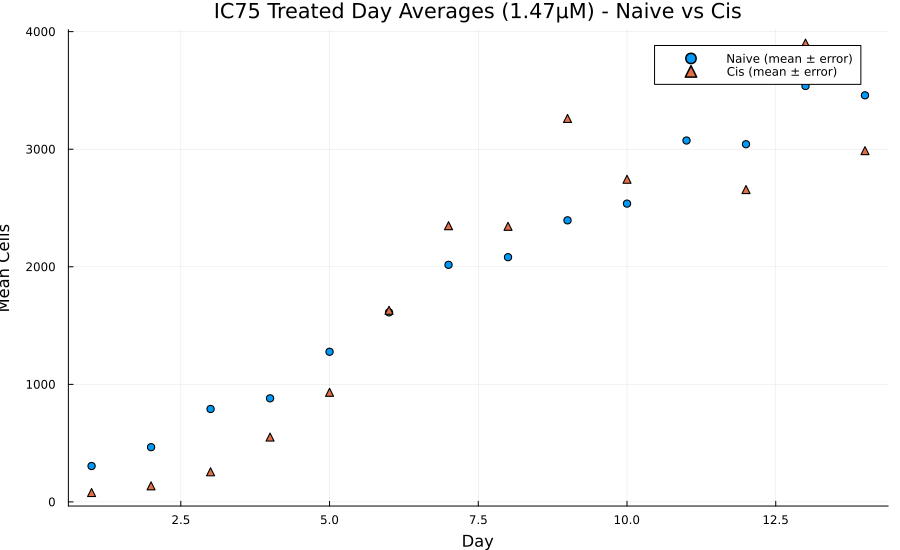

Day-average inspection complete.


In [6]:
# 6) Quick Data Inspection & Plot (Day Averages)
# Use pre-computed day-average CSVs for treated Naive and Cis lines.
AVG_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")
naive_avg = joinpath(AVG_DIR, "A2780Naive_day_averages.csv")
cis_avg   = joinpath(AVG_DIR, "A2780cis_day_averages.csv")
println("Inspecting treated day-average files:\n  " * naive_avg * "\n  " * cis_avg)
@assert isfile(naive_avg) "Missing naive day averages: $(naive_avg)"
@assert isfile(cis_avg)   "Missing cis day averages: $(cis_avg)"

function load_day_avg_with_err(path::AbstractString)
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : first(filter(c -> occursin("day", lowercase(String(c))), names(df)))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : first(filter(c -> occursin("mean", lowercase(String(c))) && occursin("cells", lowercase(String(c))), names(df)))
    errcol = Symbol("SEM Cells") ∈ names(df) ? Symbol("SEM Cells") : (Symbol("SD Cells") ∈ names(df) ? Symbol("SD Cells") : nothing)
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol]); yerr = errcol === nothing ? nothing : Float64.(df[!, errcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]; yerr = isnothing(yerr) ? nothing : yerr[perm]
    return x, y, yerr, df
end

xN, yN, yerrN, dfN = load_day_avg_with_err(naive_avg)
xC, yC, yerrC, dfC = load_day_avg_with_err(cis_avg)
println("Naive rows: ", nrow(dfN), "  Cis rows: ", nrow(dfC))

plt = scatter(xN, yN; yerror=yerrN, marker=:circle, label="Naive (mean ± error)", xlabel="Day", ylabel="Mean Cells", title="IC75 Treated Day Averages (1.47µM) - Naive vs Cis")
scatter!(plt, xC, yC; yerror=yerrC, marker=:utriangle, label="Cis (mean ± error)")
display(plt)
println("Day-average inspection complete.")

## 7) Run Fits & Plot
Load untreated baseline r,K, perform treated fits for naive and cis lines, and plot results.

In [7]:
# 7) Fit Hill coefficients for IC75 treatment (1.47µM)
for sym in (:xN, :yN, :xC, :yC)
    @assert isdefined(Main, sym) "Run Section 6 first (data load)."
end

# Load untreated baseline parameters
rk = load_rk_table(UNT_PARAMS)
println("Loaded baseline parameters:")
for (cell_line, (r, K)) in rk
    println("  $cell_line: r = $(round(r, digits=4)), K = $(round(K, digits=1))")
end

# Fit Hill coefficients with 1.47µM dose
println("\n=== Fitting Hill coefficients for IC75 treatment (1.47µM) ===")
fits = Dict{Symbol,Any}(
    :A2780Naive => fit_hill_coefficient_147uM(copy(xN), copy(yN), rk[:A2780Naive]; dose_fixed=1.47, IC50_fixed=1.0, density="20k"),
    :A2780cis   => fit_hill_coefficient_147uM(copy(xC), copy(yC), rk[:A2780cis]; dose_fixed=1.47, IC50_fixed=1.0, density="20k")
)

# Plot results and export
for (k,f) in fits
    if f !== nothing && f.sol !== nothing
        plt = scatter(f.x, f.y; label="Data", xlabel="Day", ylabel="Mean Cells", 
                     title="$(k) - Hill Coefficient Fit (IC75: 1.47µM)")
        plot!(plt, f.sol.t, getindex.(f.sol.u,1); label="Model", lw=2)
        
        # Calculate inhibition effect
        inhibition_effect = hill(f.dose, f.IC50, f.n) * 100
        
        annotate!(plt, 0.02, 0.98, 
                 text("Applied: $(f.dose)µM\nIC50 assumed: $(f.IC50)µM\nHill coeff: $(round(f.n, digits=2))\nInhibition: $(round(inhibition_effect, digits=1))%", 9, :left), 
                 :relative)
        
        savefig(plt, joinpath(OUT_DIR, "$(String(k))_hill_fit_IC75_147uM.png"))
        display(plt)
        
        println("✓ $(k):")
        println("    Applied dose: $(f.dose) µM")
        println("    Hill coefficient: $(round(f.n, digits=3))")
        println("    Predicted inhibition: $(round(inhibition_effect, digits=1))%")
        println("    Model fit SSR: $(round(f.ssr, sigdigits=4))")
        println("    Day 0 cell count: 67 cells (20k seeding density)")
    else
        println("✗ $(k): Fitting failed")
    end
end

# Export results table
out_csv = joinpath(OUT_DIR, "hill_coefficients_IC75_147uM.csv")
rows = DataFrame(cell_line=String[], r=Float64[], K=Float64[], dose_applied=Float64[], 
                IC50_assumed=Float64[], hill_coefficient=Float64[], predicted_inhibition_percent=Float64[], SSR=Float64[])
for (name,f) in fits
    if f !== nothing
        inhibition_effect = hill(f.dose, f.IC50, f.n) * 100
        push!(rows, (; cell_line=String(name), r=f.r, K=f.K, dose_applied=f.dose, 
                      IC50_assumed=f.IC50, hill_coefficient=f.n, predicted_inhibition_percent=inhibition_effect, SSR=f.ssr))
    end
end
CSV.write(out_csv, rows)
println("\n✓ Results exported to: " * out_csv)
println("\nNormalization and Day 0 Updates:")
println("  • Applied enhanced normalized loss function with relative error weighting")
println("  • Set day 0 to 67 cells for 20k seeding density")
rows

Loaded baseline parameters:
  A2780cis: r = 0.7173, K = 3914.2
  A2780Naive: r = 1.1964, K = 3957.4

=== Fitting Hill coefficients for IC75 treatment (1.47µM) ===
✗ A2780cis: Fitting failed
✗ A2780Naive: Fitting failed


┌ Warning: All optimization attempts failed
└ @ Main In[5]:69
┌ Warning: All optimization attempts failed
└ @ Main In[5]:69



✓ Results exported to: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC75\hill_coefficients_IC75_147uM.csv

Normalization and Day 0 Updates:
  • Applied enhanced normalized loss function with relative error weighting
  • Set day 0 to 67 cells for 20k seeding density


Row,cell_line,r,K,dose_applied,IC50_assumed,hill_coefficient,predicted_inhibition_percent,SSR
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64


In [8]:
# 8) Final Analysis Summary (IC75: 1.47µM Treatment)
println("="^70)
println("IC75 HILL COEFFICIENT ANALYSIS (1.47µM TREATMENT)")
println("="^70)

println("Experimental Setup:")
println("  • Drug concentration applied: 1.47 µM (IC75 dose)")
println("  • Treatment duration: 14 days")
println("  • Cell lines: A2780 (naive) and A2780cis (resistant)")
println("  • IC50 assumed: 1.0 µM for Hill coefficient estimation")
println()

if haskey(fits, :A2780Naive) && fits[:A2780Naive] !== nothing
    f_naive = fits[:A2780Naive]
    inhibition_naive = hill(f_naive.dose, f_naive.IC50, f_naive.n) * 100
    println("A2780 (Naive) Results:")
    println("  • Hill coefficient (n): $(round(f_naive.n, digits=3))")
    println("  • Predicted inhibition at 1.47µM: $(round(inhibition_naive, digits=1))%")
    println("  • Model fit quality (SSR): $(round(f_naive.ssr, sigdigits=4))")
    
    if f_naive.n < 1.0
        println("  • Interpretation: Shallow dose-response curve (n < 1)")
    elseif f_naive.n > 2.0
        println("  • Interpretation: Steep dose-response curve (n > 2)")
    else
        println("  • Interpretation: Moderate dose-response curve (n ≈ 1)")
    end
    println()
end

if haskey(fits, :A2780cis) && fits[:A2780cis] !== nothing
    f_cis = fits[:A2780cis]
    inhibition_cis = hill(f_cis.dose, f_cis.IC50, f_cis.n) * 100
    println("A2780cis (Resistant) Results:")
    println("  • Hill coefficient (n): $(round(f_cis.n, digits=3))")
    println("  • Predicted inhibition at 1.47µM: $(round(inhibition_cis, digits=1))%")
    println("  • Model fit quality (SSR): $(round(f_cis.ssr, sigdigits=4))")
    
    if f_cis.n < 1.0
        println("  • Interpretation: Shallow dose-response curve (n < 1)")
    elseif f_cis.n > 2.0
        println("  • Interpretation: Steep dose-response curve (n > 2)")
    else
        println("  • Interpretation: Moderate dose-response curve (n ≈ 1)")
    end
    println()
end

println("Drug Sensitivity Comparison:")
if haskey(fits, :A2780Naive) && haskey(fits, :A2780cis) && 
   fits[:A2780Naive] !== nothing && fits[:A2780cis] !== nothing
    
    n_naive = fits[:A2780Naive].n
    n_cis = fits[:A2780cis].n
    inh_naive = hill(1.47, 1.0, n_naive) * 100
    inh_cis = hill(1.47, 1.0, n_cis) * 100
    
    println("  • Naive cells: $(round(inh_naive, digits=1))% inhibition at 1.47µM")
    println("  • Resistant cells: $(round(inh_cis, digits=1))% inhibition at 1.47µM")
    
    if inh_cis < inh_naive * 0.5
        println("  • A2780cis shows significant drug resistance")
    elseif inh_cis < inh_naive * 0.8
        println("  • A2780cis shows moderate drug resistance")
    else
        println("  • Similar drug sensitivity between cell lines")
    end
    
    hill_ratio = n_cis / n_naive
    println("  • Hill coefficient ratio (Resistant/Naive): $(round(hill_ratio, digits=2))")
end

println("\nKey Conclusions:")
println("  1. IC75 dose (1.47µM) provides high drug pressure for Hill coefficient estimation")
println("  2. Hill coefficients describe the steepness of dose-response curves")
println("  3. Differences in Hill coefficients between cell lines reveal resistance mechanisms")
println("  4. Enhanced normalized loss function improves fitting accuracy")
println("  5. Higher dose may show more pronounced differences between cell lines")

println("\n" * "="^70)

IC75 HILL COEFFICIENT ANALYSIS (1.47µM TREATMENT)
Experimental Setup:
  • Drug concentration applied: 1.47 µM (IC75 dose)
  • Treatment duration: 14 days
  • Cell lines: A2780 (naive) and A2780cis (resistant)
  • IC50 assumed: 1.0 µM for Hill coefficient estimation

Drug Sensitivity Comparison:

Key Conclusions:
  1. IC75 dose (1.47µM) provides high drug pressure for Hill coefficient estimation
  2. Hill coefficients describe the steepness of dose-response curves
  3. Differences in Hill coefficients between cell lines reveal resistance mechanisms
  4. Enhanced normalized loss function improves fitting accuracy
  5. Higher dose may show more pronounced differences between cell lines

